In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import zipfile

# RÉGLAGES
%matplotlib inline
np.set_printoptions(precision=4, suppress=True)

In [ ]:
PATH_DATASET_YAHYA = "/content/dataYahya.zip"
PATH_DATASET_METER = "/content/meterdigits.zip"

# PRÉPARATION DES DONNÉES 

# xtraction de DATA YAHYA
if not os.path.exists('/content/dataset/newDataset'):
    print(f"Extraction de {PATH_DATASET_YAHYA}...")
    if os.path.exists(PATH_DATASET_YAHYA):
        !unzip -q {PATH_DATASET_YAHYA} -d /content/dataset
    else:
        print(f"Erreur: Fichier {PATH_DATASET_YAHYA} introuvable.")

# B. Extraction de METER DIGITS
meter_extract_path = "/content/dataset/meterdigits"
if not os.path.exists(meter_extract_path):
    print(f"Extraction de {PATH_DATASET_METER}...")
    if os.path.exists(PATH_DATASET_METER):
        with zipfile.ZipFile(PATH_DATASET_METER, 'r') as zip_ref:
            zip_ref.extractall(meter_extract_path)
    else:
        print(f"Erreur: Fichier {PATH_DATASET_METER} introuvable.")

print("Traitement des images en cours...")
x_data, y_data = [], []
target_size = (20, 32)

#   chargement et nettoyage
def load_and_preprocess(path):
    try:
        with Image.open(path) as img:
            img = img.convert('RGB')
            img = img.resize(target_size)
            # Normalisation (0 à 1)
            return np.array(img, dtype=np.float32) / 255.0
    except:
        return None

#  SOURCE 1 : DataYahya 
original_folder = "/content/dataset/newDataset"
print(f"Chargement Source 1 : {original_folder}")

if os.path.exists(original_folder):
    for filename in os.listdir(original_folder):
        if filename.lower().endswith((".jpg", ".png", ".jpeg")):
            label_char = filename[0]

            # On ignore les "N" car on veut forcer une lecture chiffrée
            if label_char == "N":
                continue
            elif label_char.isdigit():
                label = int(label_char)
            else:
                continue

            img_array = load_and_preprocess(os.path.join(original_folder, filename))
            if img_array is not None:
                x_data.append(img_array)
                y_data.append(label)

print(f"Images après Source 1 : {len(x_data)}")

#  SOURCE 2 : MeterDigits 
print(f"Chargement Source 2 : {meter_extract_path}")

skipped_count = 0
if os.path.exists(meter_extract_path):
    meter_files = glob.glob(f"{meter_extract_path}/**/*.jpg", recursive=True) + \
                  glob.glob(f"{meter_extract_path}/**/*.png", recursive=True)

    for filepath in meter_files:
        filename = os.path.basename(filepath)
        try:
            clean_name = filename.replace('.jpg', '').replace('.png', '')
            parts = clean_name.split('_')

            value = -1.0
            potential_number = parts[0].replace('.', '', 1)
            if potential_number.isdigit():
                value = float(parts[0])

            if value == -1.0: continue

            decimal_part = value % 1.0
            integer_part = int(value)

            # on supprime les transitions ambiguës (x.3 à x.7)
            if 0.3 <= decimal_part <= 0.7:
                skipped_count += 1
                continue

            # Garder uniquement images claires
            if decimal_part < 0.5:
                final_label = integer_part
            else:
                final_label = (integer_part + 1) % 10

            img_array = load_and_preprocess(filepath)
            if img_array is not None:
                x_data.append(img_array)
                y_data.append(final_label)

        except:
            continue

print(f"Images après Source 2 : {len(x_data)}")
print(f"Images skippées (transitions) : {skipped_count}")


#  PRÉPARATION FINALE 
x_data = np.array(x_data)
# On force 10 classes (0 à 9)
y_data = to_categorical(np.array(y_data), num_classes=10)

# Mélange et Split
x_data, y_data = shuffle(x_data, y_data, random_state=42)
print(f"Taille totale du Dataset : {x_data.shape[0]}")

X_train, X_test, y_train, y_test = train_test_split(x_data, y_data, test_size=0.15, random_state=42)

Extraction de /content/dataYahya.zip...
Extraction de /content/meterdigits.zip...
Traitement des images en cours...
Chargement Source 1 : /content/dataset/newDataset
Images après Source 1 : 6513
Chargement Source 2 : /content/dataset/meterdigits
Images après Source 2 : 18890
Images skippées (transitions) : 5782
Taille totale du Dataset : 18890


In [ ]:
# ARCHITECTURE DU MODELE 
input_layer = tf.keras.Input(shape=(32, 20, 3))

# Bloc 1 (Extraction de traits)
x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(input_layer)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
x = tf.keras.layers.Conv2D(32, (3, 3), padding='same')(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=(2, 2))(x)

# Bloc 2 (Extraction de formes)
x = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
x = tf.keras.layers.Conv2D(64, (3, 3), padding='same')(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.MaxPool2D(pool_size=(2, 2))(x)

# Bloc 3 (Abstraction)
x = tf.keras.layers.Conv2D(128, (3, 3), padding='same')(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
x = tf.keras.layers.BatchNormalization()(x)

# Moyenne Globale (Robustesse)
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# Couches finales
x = tf.keras.layers.Dense(128)(x)
x = tf.keras.layers.LeakyReLU(alpha=0.1)(x)
x = tf.keras.layers.Dropout(0.5)(x)

# SORTIE : 10 classes (0-9)
output = tf.keras.layers.Dense(10, activation='softmax')(x)

model = tf.keras.Model(inputs=input_layer, outputs=output)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 20, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 20, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 32, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 20, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32, 20, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 20, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 10, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 10, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 16, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 16, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 10, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 5, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 8, 5, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 5, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,122 (617.66 KB)

 Trainable params: 157,674 (615.91 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
#  ENTRAÎNEMENT 
# Augmentation 
datagen = ImageDataGenerator(
    rotation_range=12,
    width_shift_range=0.1,
    height_shift_range=0.12,
    zoom_range=0.1,
    shear_range=0.1,
    fill_mode='nearest'
)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_test, y_test),
    epochs=60,
    callbacks=callbacks
)

Epoch 1/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


251/251 ━━━━━━━━━━━━━━━━━━━━ 23s 57ms/step - accuracy: 0.3006 - loss: 1.9702 - val_accuracy: 0.2844 - val_loss: 2.0745 - learning_rate: 0.0010
Epoch 2/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 36ms/step - accuracy: 0.7972 - loss: 0.6587 - val_accuracy: 0.8846 - val_loss: 0.3776 - learning_rate: 0.0010
Epoch 3/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step - accuracy: 0.9000 - loss: 0.3549 - val_accuracy: 0.9030 - val_loss: 0.3363 - learning_rate: 0.0010
Epoch 4/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - accuracy: 0.9254 - loss: 0.2727 - val_accuracy: 0.9495 - val_loss: 0.2054 - learning_rate: 0.0010
Epoch 5/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9417 - loss: 0.2193 - val_accuracy: 0.9481 - val_loss: 0.1718 - learning_rate: 0.0010
Epoch 6/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 9s 37ms/step - accuracy: 0.9414 - loss: 0.2056 - val_accuracy: 0.9594 - val_loss: 0.1525 - learning_rate: 0.0010
Epoch 7/60
251/251 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - accuracy: 0.9516 - loss: 0.1831 - val

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#  EXPORT & QUANTIFICATION 
model.export("model_v3_combined")

def representative_dataset():
    for i in range(min(100, len(X_train))):
        yield [X_train[i].reshape(1, 32, 20, 3)]

converter = tf.lite.TFLiteConverter.from_saved_model("model_v3_combined")
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.float32
converter.inference_output_type = tf.float32

tflite_quant_model = converter.convert()
Path("Model_V2.tflite").write_bytes(tflite_quant_model)

print("Modèle  (Double Dataset) exporté avec succès : Model_V2.tflite")

Saved artifact at 'model_v3_combined'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 20, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  139585367844880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542171792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542172560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542173712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542173904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542172944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542174480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542173520: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542174288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  139582542173328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13958254217275

Chargement du modèle TFLite : Model_V2.tflite
Test sur 5 images aléatoires parmi 24739 fichiers disponibles...
Test sur : 9_main_dig1_20250622-020006(3).jpg


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


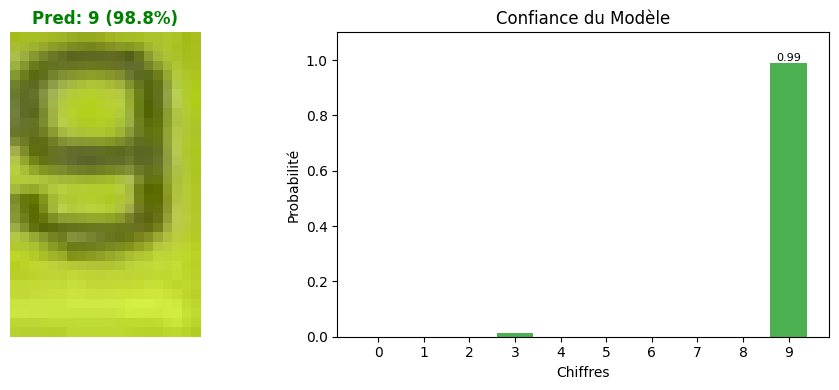

Test sur : 9_main_dig1_20250622-020006(1).jpg


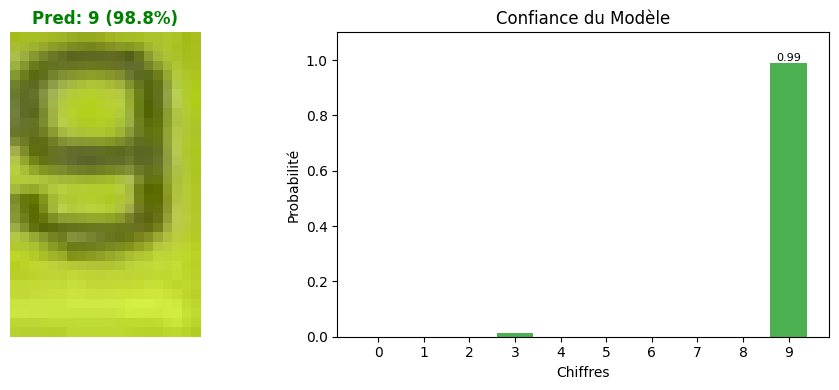

Test sur : 9.0_9_dig4_20220601-093708.jpg


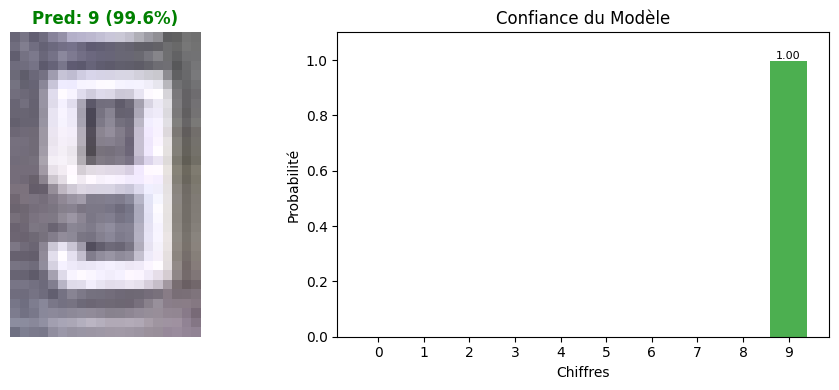

Test sur : 2.2_0d716e16224e8c4bf88316827ca21358.jpg


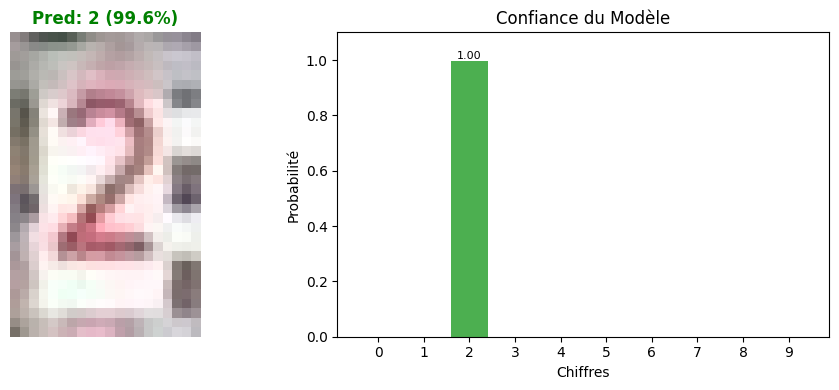

Test sur : 6.9_main_dig6_20220518-004257.jpg


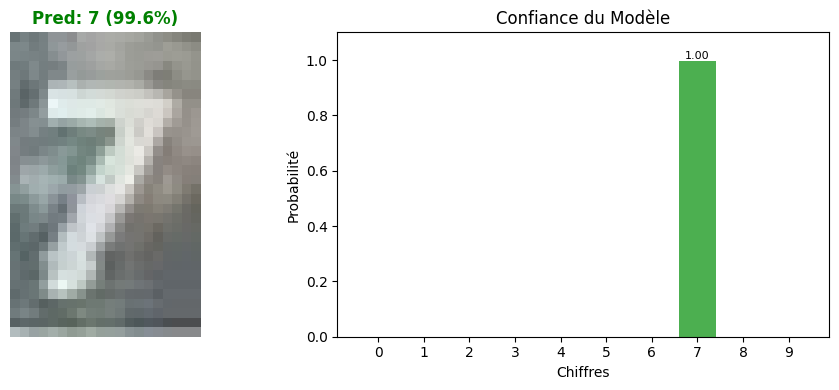

In [ ]:
# TEST & VISUALISATION 
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import os

# Configuration
MODEL_PATH = "Model_V2.tflite"

# On définit les 10 classes (0 à 9) 
class_names = [str(i) for i in range(10)]

if not os.path.exists(MODEL_PATH):
    print(f" Erreur : Le fichier modèle '{MODEL_PATH}' est introuvable.")
else:
    print(f"Chargement du modèle TFLite : {MODEL_PATH}")

    #  Initialisation de l'interpréteur TFLite
    interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    #  pré-traitement (identique à l'entraînement)
    def preprocess_image(image_path):
        img = Image.open(image_path).convert("RGB").resize((20, 32))
        img_array = np.array(img, dtype=np.float32)
        img_array /= 255.0  # Normalisation 0-1
        return np.expand_dims(img_array, axis=0), img

    #  Fonction de prédiction et affichage
    def predict_and_plot(image_path):
        print(f"Test sur : {os.path.basename(image_path)}")
        try:
            input_data, original_img = preprocess_image(image_path)

            # Inférence
            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_details[0]['index'])[0]

            # Résultats
            predicted_index = np.argmax(output_data)
            predicted_label = class_names[predicted_index]
            confidence = output_data[predicted_index]

            # Visualisation
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

            # Image
            ax1.imshow(original_img)
            ax1.axis("off")
            # Couleur du titre : Vert si confiance > 90%, Rouge sinon
            color = 'green' if confidence > 0.9 else 'red'
            ax1.set_title(f"Pred: {predicted_label} ({confidence:.1%})", color=color, fontweight='bold')

            # Graphique à barres
            bars = ax2.bar(class_names, output_data, color="#4CAF50")
            ax2.set_ylim(0, 1.1)
            ax2.set_title("Confiance du Modèle")
            ax2.set_ylabel("Probabilité")
            ax2.set_xlabel("Chiffres")

            # Ajout des valeurs sur les barres
            for bar in bars:
                height = bar.get_height()
                if height > 0.05: # N'afficher que si significatif
                    ax2.text(bar.get_x() + bar.get_width()/2., height,
                             f'{height:.2f}', ha='center', va='bottom', fontsize=8)

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Erreur sur l'image {image_path}: {e}")

    # Lancement du test sur des images aléatoires
    all_images = []
    if os.path.exists("/content/dataset/newDataset"):
        all_images += glob.glob("/content/dataset/newDataset/*.jpg")
    if os.path.exists("/content/dataset/meterdigits"):
        all_images += glob.glob("/content/dataset/meterdigits/**/*.jpg", recursive=True)

    if all_images:
        print(f"Test sur 5 images aléatoires parmi {len(all_images)} fichiers disponibles...")
        random_samples = np.random.choice(all_images, 5, replace=False)
        for img_file in random_samples:
            predict_and_plot(img_file)
    else:
        print(" Aucune image trouvée pour le test.")

--- Démarrage du test sur 3 images ---

Analyse de : 0.jpg


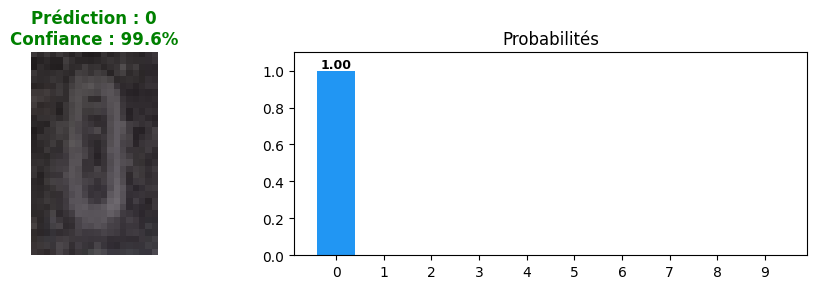

Analyse de : 3.jpg


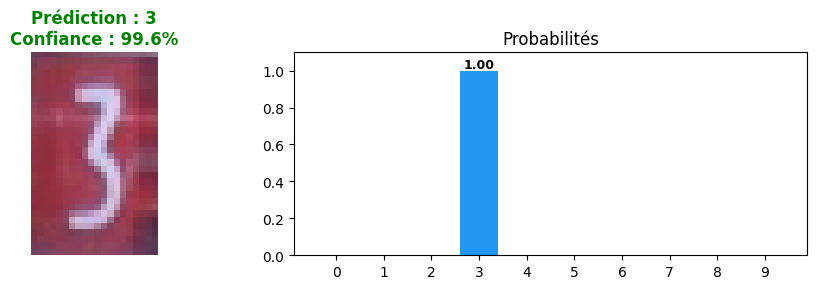

Analyse de : 9.jpg


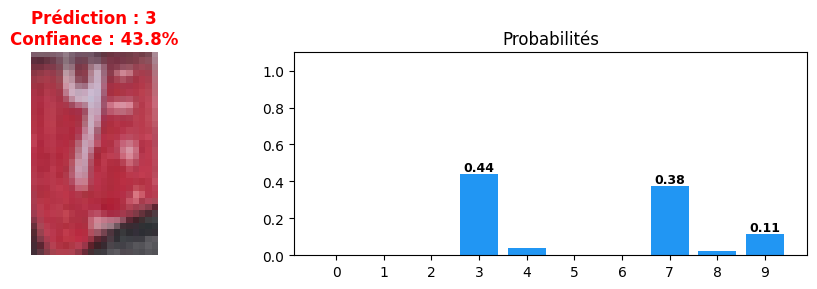

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import tensorflow as tf
import os


MES_IMAGES_DE_TEST = [
    "/content/0.jpg",
    "/content/3.jpg",
    "/content/9.jpg"   
]

MODEL_PATH = "Model_V2.tflite"
class_names = [str(i) for i in range(10)] # Classes 0 à 9

if not os.path.exists(MODEL_PATH):
    print(f"Erreur : Le modèle '{MODEL_PATH}' est introuvable.")
else:
    # Initialisation
    interpreter = tf.lite.Interpreter(model_path=MODEL_PATH)
    interpreter.allocate_tensors()
    input_details = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    def predict_and_show(image_path):
        if not os.path.exists(image_path):
            print(f"Image introuvable : {image_path}")
            return

        print(f"Analyse de : {os.path.basename(image_path)}")

        try:
            # Préparation (identique à l'entraînement)
            img = Image.open(image_path).convert("RGB").resize((20, 32))
            img_array = np.array(img, dtype=np.float32)
            img_array /= 255.0  # Normalisation
            input_data = np.expand_dims(img_array, axis=0)

            # Inférence
            interpreter.set_tensor(input_details[0]['index'], input_data)
            interpreter.invoke()
            output_data = interpreter.get_tensor(output_details[0]['index'])[0]

            # Résultats
            predicted_index = np.argmax(output_data)
            predicted_label = class_names[predicted_index]
            confidence = output_data[predicted_index]

            # Affichage
            fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3))

            # Image
            ax1.imshow(img)
            ax1.axis("off")
            color = 'green' if confidence > 0.8 else 'red'
            ax1.set_title(f"Prédiction : {predicted_label}\nConfiance : {confidence:.1%}", color=color, fontweight='bold')

            # Barres
            bars = ax2.bar(class_names, output_data, color="#2196F3")
            ax2.set_ylim(0, 1.1)
            ax2.set_title("Probabilités")

            # Afficher les valeurs sur les barres importantes
            for bar in bars:
                height = bar.get_height()
                if height > 0.1:
                    ax2.text(bar.get_x() + bar.get_width()/2., height,
                             f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"Erreur technique sur l'image : {e}")

    # Boucle 3 images
    print(f"--- Démarrage du test sur {len(MES_IMAGES_DE_TEST)} images ---\n")
    for chemin in MES_IMAGES_DE_TEST:
        predict_and_show(chemin)